**Preparação do ambiente**

Baixar o dataset que está no meu github e extrair o dataset

In [1]:
system("git clone https://github.com/Raulim-EP/Predi-o-de-insufici-ncia-cardi-ca-com-base-em-indicadores-cl-nicos.git")
system("unzip -u Predi-o-de-insufici-ncia-cardi-ca-com-base-em-indicadores-cl-nicos/dataset/heart+failure+clinical+records.zip")

**Instalação das bibliotecas**

Instalar bibliotecas necessárias para o projeto

In [12]:
install.packages("rpart")
install.packages("rpart.plot")
#install.packages("caret")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



**Importar as bibliotecas**

In [13]:
library("rpart")
library("rpart.plot")
#library("caret")

**Variável data**

Na variável data está armazenada todo o conteúdo do dataset

In [2]:
data <- read.csv("./heart_failure_clinical_records_dataset.csv")

**Conhecendo o dataset**

In [5]:
#exibir a estrutura do objeto (data), mostra toda a estrutura do nosso dataset
str(data)

'data.frame':	299 obs. of  13 variables:
 $ age                     : num  75 55 65 50 65 90 75 60 65 80 ...
 $ anaemia                 : int  0 0 0 1 1 1 1 1 0 1 ...
 $ creatinine_phosphokinase: int  582 7861 146 111 160 47 246 315 157 123 ...
 $ diabetes                : int  0 0 0 0 1 0 0 1 0 0 ...
 $ ejection_fraction       : int  20 38 20 20 20 40 15 60 65 35 ...
 $ high_blood_pressure     : int  1 0 0 0 0 1 0 0 0 1 ...
 $ platelets               : num  265000 263358 162000 210000 327000 ...
 $ serum_creatinine        : num  1.9 1.1 1.3 1.9 2.7 2.1 1.2 1.1 1.5 9.4 ...
 $ serum_sodium            : int  130 136 129 137 116 132 137 131 138 133 ...
 $ sex                     : int  1 1 1 1 0 1 1 1 0 1 ...
 $ smoking                 : int  0 0 1 0 0 1 0 1 0 1 ...
 $ time                    : int  4 6 7 7 8 8 10 10 10 10 ...
 $ DEATH_EVENT             : int  1 1 1 1 1 1 1 1 1 1 ...


In [6]:
#Mostra o sumário do nosso dataset
summary(data)

      age           anaemia       creatinine_phosphokinase    diabetes     
 Min.   :40.00   Min.   :0.0000   Min.   :  23.0           Min.   :0.0000  
 1st Qu.:51.00   1st Qu.:0.0000   1st Qu.: 116.5           1st Qu.:0.0000  
 Median :60.00   Median :0.0000   Median : 250.0           Median :0.0000  
 Mean   :60.83   Mean   :0.4314   Mean   : 581.8           Mean   :0.4181  
 3rd Qu.:70.00   3rd Qu.:1.0000   3rd Qu.: 582.0           3rd Qu.:1.0000  
 Max.   :95.00   Max.   :1.0000   Max.   :7861.0           Max.   :1.0000  
 ejection_fraction high_blood_pressure   platelets      serum_creatinine
 Min.   :14.00     Min.   :0.0000      Min.   : 25100   Min.   :0.500   
 1st Qu.:30.00     1st Qu.:0.0000      1st Qu.:212500   1st Qu.:0.900   
 Median :38.00     Median :0.0000      Median :262000   Median :1.100   
 Mean   :38.08     Mean   :0.3512      Mean   :263358   Mean   :1.394   
 3rd Qu.:45.00     3rd Qu.:1.0000      3rd Qu.:303500   3rd Qu.:1.400   
 Max.   :80.00     Max.   :1.0

In [7]:
#Retorna os valores únicos permitidos para a variável alvo
#Ela retornará null já que ainda está em binário ou seja 0 e 1
levels(data$DEATH_EVENT)

NULL

**Preprocessamento**

Tranformar a variável DEATH_EVENT em fator, ao invés de binária 0 ou 1, será Vivo ou Óbito

In [8]:
#Importante para classificar, labels deve ser = a level, para não dar erro
data$DEATH_EVENT <- factor(data$DEATH_EVENT, level = c(0, 1), labels = c("Vivo", "Óbito"))

Agora ao visualizar os valores únicos veremos Vivo e Óbito

In [9]:
levels(data$DEATH_EVENT)

[1] "Vivo"  "Óbito"

Dividir a coluna inteira das plaquetas (platelets) por mil, para facilitar processamento

In [10]:
library("dplyr")

data <- data %>%
  mutate(platelets = platelets / 1000)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




Separar em index 80% do dataset

In [14]:
index <- createDataPartition(data$DEATH_EVENT, p= 0.80, list = FALSE)
testset <- data[-index, ] #testset terá -index ou seja sem ser os 80%, então será os 20%
trainset <- data[index,] #trainset terá index ou seja os 80%

ERROR: Error in createDataPartition(data$DEATH_EVENT, p = 0.8, list = FALSE): could not find function "createDataPartition"


Criei uma árvore de decisão comparando os resultados de DEATH_EVENT com todas as outras variáveis do dataset para saber a relevância de cada variável nos nós da árvore.

In [ ]:
modelo <- rpart(DEATH_EVENT ~., data = data, method="class")
modelo$variable.importance

time         serum_creatinine        ejection_fraction 
              59.2132956               12.7945383                5.6400831 
                     age             serum_sodium creatinine_phosphokinase 
               5.5031224                3.4776418                2.9970711 
               platelets                  smoking                 diabetes 
               2.0801488                1.0758785                0.3105811 
                     sex 
               0.2450001

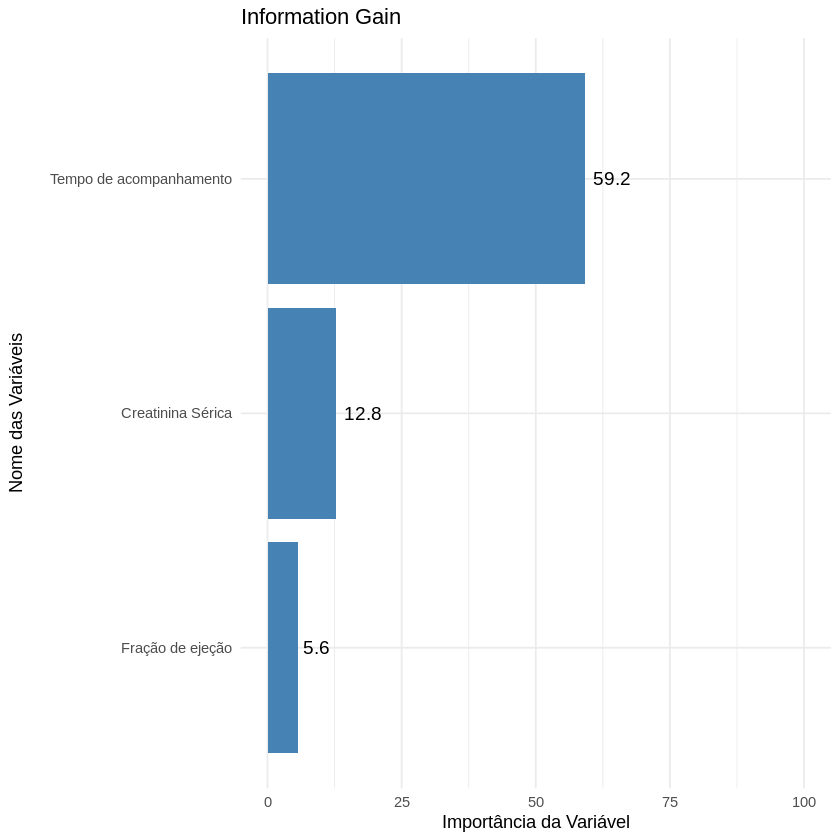

In [ ]:
library(ggplot2)

dados <- data.frame(
  variavel = c("Tempo de acompanhamento", "Creatinina Sérica", "Fração de ejeção"),
  importancia = c(59.2, 12.8, 5.6)
)

ggplot(dados, aes(x = importancia, y = reorder(variavel, importancia))) +
  geom_col(fill = "steelblue") +
  geom_text(aes(label = importancia), hjust = -0.2, size = 4) +
  labs(
    title = "Information Gain",
    x = "Importância da Variável",
    y = "Nome das Variáveis"
  ) +
  theme_minimal() +
  xlim(0, 100)

Fiz a árvore de decisão apartir das 3 variáveis mais importantes e plotei ela, ou seja, imprimi ela.

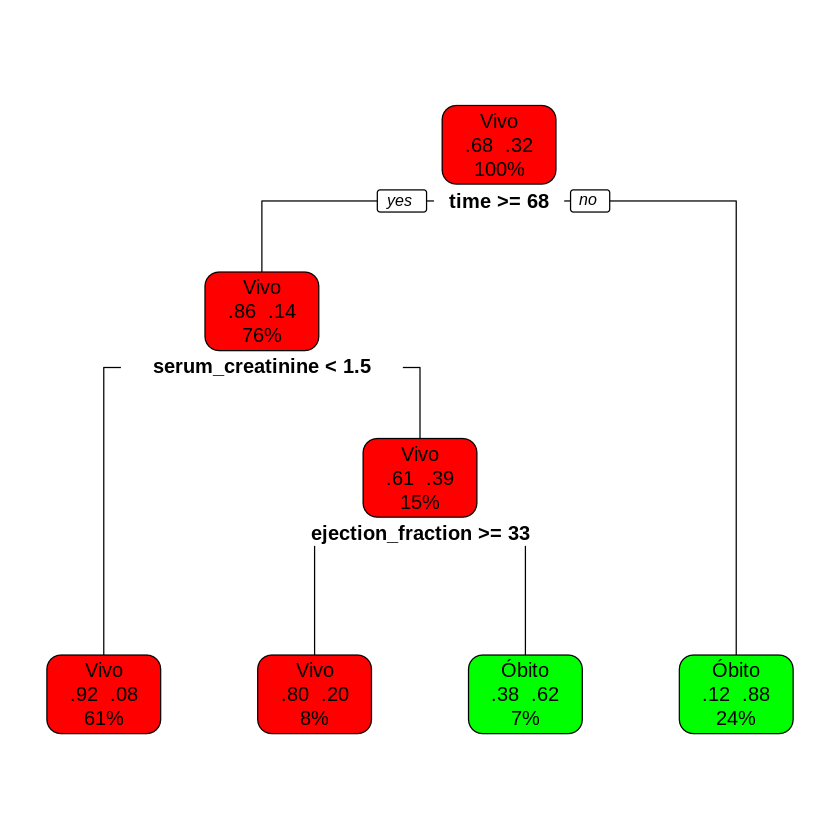

In [ ]:
set.seed(1)
modeltree <- rpart(DEATH_EVENT ~ serum_creatinine + ejection_fraction + time, data = trainset, method = "class")
rpart.plot(modeltree, extra = 104 , box.palette = list("red","green","yellow"))

Criei a matriz de confusão do meu modelo, aplicada no trainset (80%)

In [ ]:
confusionMatrix(predict(object = modeltree,newdata = trainset,type="class"),trainset$DEATH_EVENT)

Confusion Matrix and Statistics

          Reference
Prediction Vivo Óbito
     Vivo   150    16
     Óbito   13    61
                                          
               Accuracy : 0.8792          
                 95% CI : (0.8311, 0.9176)
    No Information Rate : 0.6792          
    P-Value [Acc > NIR] : 4.885e-13       
                                          
                  Kappa : 0.7199          
                                          
 Mcnemar's Test P-Value : 0.7103          
                                          
            Sensitivity : 0.9202          
            Specificity : 0.7922          
         Pos Pred Value : 0.9036          
         Neg Pred Value : 0.8243          
             Prevalence : 0.6792          
         Detection Rate : 0.6250          
   Detection Prevalence : 0.6917          
      Balanced Accuracy : 0.8562          
                                          
       'Positive' Class : Vivo            
                     

No objeto pred, coloquei uma tabela mostrando quantos pacientes meu modelo preditou Vivo e quanto preditou Óbito

In [ ]:
pred<-table(predict(object = modeltree,newdata = trainset[,1:12],type="class"))
pred


 Vivo Óbito 
  170    70 

Matriz confusão aplicada no meu testset (20%)

In [ ]:
pred_test<-predict(object = modeltree,
                   newdata = testset[,1:12],
                   type="class")
confusionMatrix(pred_test,testset$DEATH_EVENT)

Confusion Matrix and Statistics

          Reference
Prediction Vivo Óbito
     Vivo    32     3
     Óbito    8    16
                                          
               Accuracy : 0.8136          
                 95% CI : (0.6909, 0.9031)
    No Information Rate : 0.678           
    P-Value [Acc > NIR] : 0.0152          
                                          
                  Kappa : 0.6006          
                                          
 Mcnemar's Test P-Value : 0.2278          
                                          
            Sensitivity : 0.8000          
            Specificity : 0.8421          
         Pos Pred Value : 0.9143          
         Neg Pred Value : 0.6667          
             Prevalence : 0.6780          
         Detection Rate : 0.5424          
   Detection Prevalence : 0.5932          
      Balanced Accuracy : 0.8211          
                                          
       'Positive' Class : Vivo            
                     

**Interpretação da Matriz de Confusão**

||Previsto:Vivo(0)|Previsto:Morto(1)|
|:---:|:---:|:---:|
|Real: Vivo(0)|Pessoas que ficaram vivas e o R acertou|O R disse que a pessoa ia morrer, mas sobreviveu|
|Real: Óbito(1)|(**PIOR**) O R disse que ia sobreviver e morreu|Pessoas que morreram e o R acertou o padrão|